# DFT Implementation 


## Exercise 1

The DFT was implemented directly from the matrix formula:

$$
X_k = \sum_{n=0}^{N-1} x_n e^{-2\pi i kn/N}
$$

This can be written in linear algebra form as:

$$
\mathbf{X} = W \mathbf{x}
$$

where the matrix entries are:

$$
W_{kn} = e^{-2\pi i kn/N}.
$$

In the code, I explicitly constructed the matrix $W$ and multiplied it by the signal vector. 

### Test

To verify the implementation, I compared the result with numpy.fft.fft using a simple test signal (in this case a simple sin wave). The results matched up to floating point error, confirming that the matrix $W$ was constructed correctly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def dft(x):
    """Compute the DFT of a 1D array x using matrix W."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

# ---- Test the DFT code ----
#test the DFT implementation against numpy's FFT using a simple sin wave

def dft_test():
    N = 64
    width = 8
    x = np.sin(2 * np.pi * 5 * np.arange(N) / N)  # sin wave with frequency 5 cycles/sample
    X = dft(x)
    X_np = np.fft.fft(x)
    print("Max difference from np.fft.fft:", np.max(np.abs(X - X_np)))

dft_test()

Max difference from np.fft.fft: 3.373282476226397e-13


## Square Pulse (Top-Hat Function) and Sampling

## Exercise 2 | Exercise 3

By changing the number of samples $N$:
Increasing $N$ decreases the time step $dt$ This improves the resolution in both time and frequency

From the plots:
For small $N$, the frequency-domain representation is coarse and does not clearly follow the expected shape
For large $N$, the DFT points more closely trace the analytical sinc curve, except at the edges where the theoretical neighbouring pulses are slightly adding to the magnitude in the fruequency domain

So increasing sampling improves how well the discrete transform represents the continuous result.

Hermitian symmetry
Since the square pulse is real-valued, its DFT satisfies X[N-k] = conj(X[k]). This means the magnitude spectrum is symmetric about zero frequency. |X[k]| = |X[N-k]|, which is visible in all the plots below.
In practice this means only the first N/2 frequency bins contain unique information, the second half is a mirror image of the first. (this is something we take advantage of in HPC to save memory)

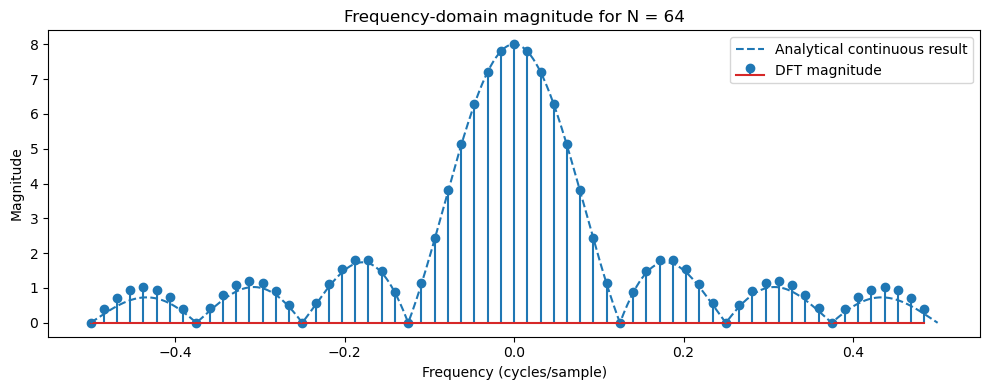

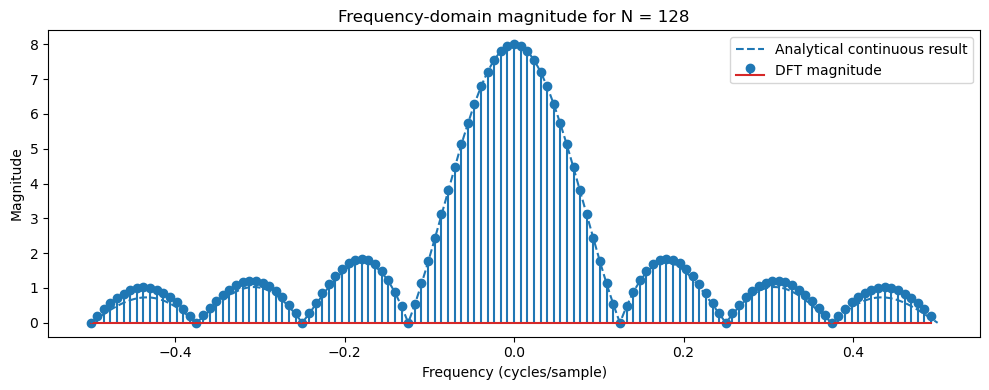

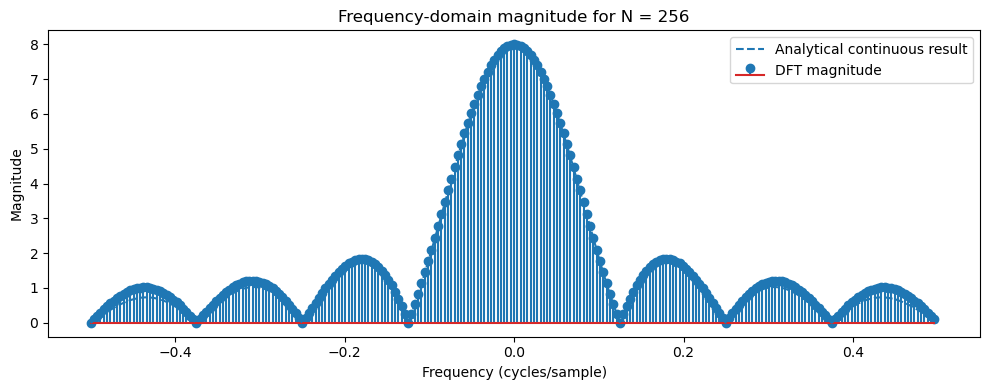

In [5]:
""" Create a square "wave" (the top-hat function). In the time domain this is a single square pulse. Try different amounts of sampling. Note 1: make the square pulse width small in comparison to the time data. Note 2: you are working with complex variables, if the pulse is real data, what is true of the transform data in the frequency domain? """

def square_pulse(N, width, start=None):
    """Generate a top-hat pulse of length N and width."""
    x = np.zeros(N, dtype=float)
    if start is None:
        start = (N - width) // 2   # center it for cleaner phase behavior
    x[start:start + width] = 1.0
    return x


def continuous_rect_dft(f, width):
    """Analytical DFT of a continuous rectangular pulse."""
    # The Fourier transform of a rectangular pulse is a sinc function
    return width * np.sinc(width * f)

#trying different amounts of sampling and plotting against the continuous analytical result
N = [64, 128, 256]
width = 8
f_cont = np.linspace(-0.5, 0.5, 1000)  # continuous frequency range for plotting
X_cont = continuous_rect_dft(f_cont, width)
for N_test in N:
    x_test = square_pulse(N_test, width)
    X_test = dft(x_test)
    freq_test = np.fft.fftfreq(N_test)

    plt.figure(figsize=(10, 4))
    plt.stem(np.fft.fftshift(freq_test), np.abs(np.fft.fftshift(X_test)), label="DFT magnitude")
    plt.plot(f_cont, np.abs(X_cont), '--', label="Analytical continuous result")
    plt.title(f"Frequency-domain magnitude for N = {N_test}")
    plt.xlabel("Frequency (cycles/sample)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.tight_layout()
    plt.show()



## Exercise 4


In the case of the earlier exercises the aliasing presented itself as slight misestimates at the edges of the sampled domain.

Aliasing occurs because the square pulse is not band-limited.
Its Fourier transform (sinc) extends infinitely in frequency. When the signal is sampled: The spectrum repeats every sampling frequency $f_s$ If $f_s$ is too small, these repeated copies overlap

In order to exagerate this the next set of plots shows the individual alias contributions in gray, summed in red at low sampling frequencies. and how increasing the sampling frequency leads to better estimates.

### How it appears in the plots:

For small $N$ (low sampling rate):
The repeated spectra are close together
They overlap significantly leads to strong aliasing

For large $N$ (high sampling rate):
The repeated spectra are farther apart
Less overlap leads to reduced aliasing

### How to reduce aliasing:

Increase the sampling rate (increase $N$)
Apply a filter 

In this case, increasing $N$ reduces aliasing but cannot eliminate it entirely because the square pulse has infinite bandwidth.

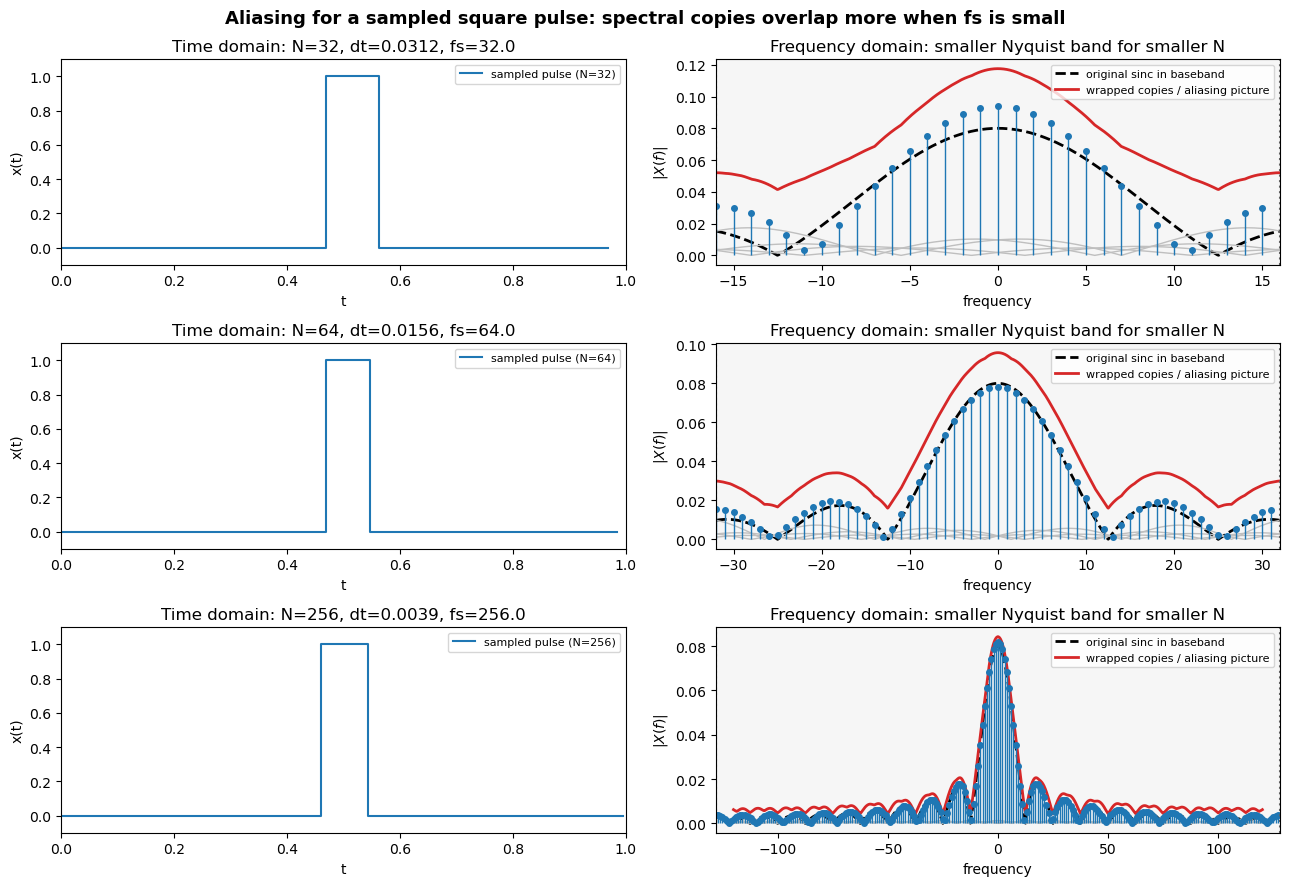

In [ ]:
def sampled_rect_from_physical_time(N, T=1.0, tau=0.08): 
    # Sample a physical rectangular pulse of width tau centered in time, 
    # sampled at N points over total duration T.
    t = np.linspace(0, T, N, endpoint=False)
    center = T / 2
    x = ((t >= center - tau/2) & (t < center + tau/2)).astype(float)
    return t, x

def continuous_rect_ft(f, tau):
    # Magnitude of the continuous-time FT of a unit-height rectangle of width tau
    # centered in time. The phase factor from centering only changes phase, not magnitude.
    return tau * np.sinc(tau * f)

# Same physical pulse, different sampling rates
T = 1.0
tau = 0.08
Ns = [32, 64, 256]

# wide frequency axis so the repeated copies are visible
f_wide = np.linspace(-120, 120, 4000)

fig, axes = plt.subplots(len(Ns), 2, figsize=(13, 9))

for row, N in enumerate(Ns):
    dt = T / N
    fs = 1 / dt
    fN = fs / 2

    t, x = sampled_rect_from_physical_time(N, T=T, tau=tau)

    # DFT samples, scaled by dt to compare with the continuous-time FT magnitude
    X = dft(x) * dt
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
    mag = np.abs(np.fft.fftshift(X))

    # left: sampled pulse in time
    ax_t = axes[row, 0]
    ax_t.step(t, x, where="post", label=f"sampled pulse (N={N})")
    ax_t.set_xlim(0, T)
    ax_t.set_ylim(-0.1, 1.1)
    ax_t.set_title(f"Time domain: N={N}, dt={dt:.4f}, fs={fs:.1f}")
    ax_t.set_xlabel("t")
    ax_t.set_ylabel("x(t)")
    ax_t.legend(fontsize=8)

    # right: baseband spectrum with spectral copies shown
    ax_f = axes[row, 1]

    # Original continuous sinc in baseband
    mask_base = (f_wide >= -fN) & (f_wide <= fN)
    ax_f.plot(f_wide[mask_base], np.abs(continuous_rect_ft(f_wide[mask_base], tau)),
              "k--", lw=2, label="original sinc in baseband")

    # Neighboring repeated copies caused by sampling
    for m in [-2, -1, 1, 2]:
        shifted = np.abs(continuous_rect_ft(f_wide - m*fs, tau))
        ax_f.plot(f_wide[mask_base], shifted[mask_base], color="0.75", lw=1)

    # Sum of the visible copies inside baseband (illustrates aliasing/folding)
    alias_sum = np.zeros_like(f_wide)
    for m in range(-6, 7):
        alias_sum += np.abs(continuous_rect_ft(f_wide - m*fs, tau))
    ax_f.plot(f_wide[mask_base], alias_sum[mask_base], color="tab:red", lw=2,
              label="wrapped copies / aliasing picture")

    # Actual DFT samples
    markerline, stemlines, baseline = ax_f.stem(freqs, mag, linefmt='C0-', markerfmt='C0o', basefmt=' ')
    plt.setp(stemlines, linewidth=1.0)
    plt.setp(markerline, markersize=4)

    ax_f.axvline(-fN, color='0.4', linestyle=':')
    ax_f.axvline( fN, color='0.4', linestyle=':')
    ax_f.axvspan(-fN, fN, color='0.9', alpha=0.35)
    ax_f.set_xlim(-fN, fN)
    ax_f.set_title(f"Frequency domain: smaller Nyquist band for smaller N")
    ax_f.set_xlabel("frequency")
    ax_f.set_ylabel(r"$|X(f)|$")
    ax_f.legend(fontsize=8, loc="upper right")

plt.suptitle("Aliasing for a sampled square pulse: spectral copies overlap more when fs is small",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Exercise 5


Although the plotted signal appears to be a single pulse from $t = 0$ to $T$, the DFT does not treat it as an isolated signal.

Instead, the DFT assumes the signal is periodic with period $T$.

This means we are actually transforming a periodic train of square pulses, not a single isolated pulse.

The time-domain signal is implicitly repeated
The frequency-domain result corresponds to this periodic extension
The DFT gives discrete frequency samples of this periodic signal

If the pulse is narrow compared to $T$, the repetitions are far apart, so the signal looks approximately like a single pulse over one interval.

However, the DFT is always computed for a periodic signal.